In [13]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar



In [14]:
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_harlequin_V3.dat"
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_006_01_Decay1.h5m"

lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [15]:
def run_decay_case(model_path, A0, exp_time, exp_signal, delta_t_exp,
                   linear_damping, quadratic_damping):
    """
    Draait 1 OrcaFlex decay case en vergelijkt met experiment.
    """

    # -------------------------
    # model opnieuw openen
    # -------------------------
    model = OrcFxAPI.Model(model_path)
    constraint = model["decay_constraint"]
    floaters = model["floaters"]
    floatertype = model["Floatertype"]

    # -------------------------
    # beginverplaatsing zetten
    # -------------------------


    # -------------------------
    constraint.InFrameInitialZ = A0
    constraint.InFrameInitialX = 0
    constraint.InFrameInitialY = 0
    constraint.InFrameInitialAzimuth = 0
    constraint.InFrameInitialDeclination = 0 
    constraint.InFrameInitialGamma = 0

    floatertype.OtherDampingLinearCoeffx = 0 #surge
    floatertype.OtherDampingLinearCoeffy = 0 #sway
    floatertype.OtherDampingLinearCoeffz  = linear_damping
    floatertype.OtherDampingLinearCoeffRx = 0 #roll
    floatertype.OtherDampingLinearCoeffRy = 0 #pitch
    floatertype.OtherDampingLinearCoeffRz = 0 #yaw

    floatertype.OtherDampingQuadraticCoeffx = 0 #surge
    floatertype.OtherDampingQuadraticCoeffy = 0 #sway 
    floatertype.OtherDampingQuadraticCoeffz = quadratic_damping #heav
    floatertype.OtherDampingQuadraticCoeffRx = 0#roll
    floatertype.OtherDampingQuadraticCoeffRy = 0 #pitch
    floatertype.OtherDampingQuadraticCoeffRz = 0 #yaw
        # run
    # -------------------------
    model.RunSimulation()

    
    t_sim = model.general.TimeHistory("Time")
    z_sim = floaters.TimeHistory("Z")

    # -------------------------
    # tijd verschuiven met experimenteel verschil
    # -------------------------
    t_sim_decay = t_sim - t_sim[0]
    t_sim_shifted = t_sim_decay - delta_t_exp

    # -------------------------
    # interpolatiefunctie
    # -------------------------
    f_sim = interp1d(
        t_sim_shifted,
        z_sim,
        bounds_error=False,
        fill_value=np.nan
    )

    # -------------------------
    # kleine extra shift fitten
    # -------------------------
    def compute_rmse(time_shift):
        z_sim_trial = f_sim(exp_time + time_shift)
        mask = ~np.isnan(z_sim_trial)

        if np.sum(mask) < 10:
            return 1e9

        error = z_sim_trial[mask] - exp_signal[mask]
        return np.sqrt(np.mean(error**2))

    result = minimize_scalar(
        compute_rmse,
        bounds=(-2.0, 2.0),
        method="bounded"
    )

    best_shift = result.x
    z_sim_fit = f_sim(exp_time + best_shift)

    mask = ~np.isnan(z_sim_fit)

    error = z_sim_fit[mask] - exp_signal[mask]
    rmse = np.sqrt(np.mean(error**2))
    mae = np.mean(np.abs(error))

    return {
        "linear_damping": linear_damping,
        "quadratic_damping": quadratic_damping,
        "best_time_shift": best_shift,
        "rmse": rmse,
        "mae": mae,
        "t_sim_shifted": t_sim_shifted,
        "z_sim": z_sim,
        "z_sim_fit": z_sim_fit,
        "mask": mask,
    }

In [16]:
with h5py.File(exp_path, "r") as f:
    t_exp = f["CroppedSignals/time"][:]
    z_exp = f["CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)"][:]
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]

# DataFrames in één keer maken
df_exp = pd.DataFrame({
    "time [s]": t_exp,
    "time_norm [s]": t_exp - t_exp[0],
    "z_exp [m]": z_exp
})

df_unfiltered = pd.DataFrame({
    "time [s]": t_unfiltered,
    "z_unfiltered [m]": z_unfiltered
})


In [17]:
t_decay_start = t_exp[0]

# -----------------------------
# 2. rustige periode in ongefilterd signaal kiezen
#    van (start - quiet_window_end - quiet_window_length) tot (start - quiet_window_end)
# -----------------------------
quiet_start = t_decay_start - quiet_window_end - quiet_window_length
quiet_end = t_decay_start - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode. Kies andere vensters.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# -----------------------------
# 3. zoekvenster voor initiële amplitude
#    10 s vóór decay-start
# -----------------------------
search_start = t_decay_start - lookback_window
search_end = t_decay_start

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in het zoekvenster vóór de decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

# afwijking t.o.v. evenwicht
deviation = z_search - z_eq

# index van grootste absolute uitslag
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0 = np.abs(z_init - z_eq)

delta_t_exp = t_decay_start - t_init
t_exp_decay = t_exp - t_decay_start

print(f"Decay start time           = {t_decay_start:.3f} s")
print(f"Quiet window               = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq     = {z_eq:.6f} m")
print(f"Search window              = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme at t       = {t_init:.3f} s")
print(f"Initial extreme z          = {z_init:.6f} m")
print(f"Initial amplitude A0       = {A0:.6f} m")
print(f"Signed amplitude           = {z_init - z_eq:.6f} m")

Decay start time           = 1087.008 s
Quiet window               = [1025.008, 1075.008] s
Equilibrium level z_eq     = 0.021210 m
Search window              = [1082.008, 1087.008] s
Initial extreme at t       = 1082.033 s
Initial extreme z          = -3.157819 m
Initial amplitude A0       = 3.179029 m
Signed amplitude           = -3.179029 m


In [18]:
target_rmse = 0.20
target_mae = 0.15

c_lin = 1
c_quad =1

step_lin = 0.2
step_quad = 0.2

min_step_lin = 0.05
min_step_quad = 0.05

max_iter = 40

result = run_decay_case(
    model_path=model_path,
    A0=A0,
    exp_time=t_exp_decay,
    exp_signal=z_exp,
    delta_t_exp=delta_t_exp,
    linear_damping=c_lin,
    quadratic_damping=c_quad
)

print("RMSE =", result["rmse"])
print("MAE  =", result["mae"])



RMSE = 1.1008348861702721
MAE  = 0.930900916939132


In [19]:
def evaluate_case(c_lin, c_quad):
    result = run_decay_case(
        model_path=model_path,
        A0=A0,
        exp_time=t_exp_decay,
        exp_signal=z_exp,
        delta_t_exp=delta_t_exp,
        linear_damping=c_lin,
        quadratic_damping=c_quad
    )
    return result

In [20]:
def random_candidates(n_samples, lin_range, quad_range):
    candidates = []

    for _ in range(n_samples):
        lin = np.random.uniform(lin_range[0], lin_range[1])
        quad = np.random.uniform(quad_range[0], quad_range[1])

        candidates.append((lin, quad))

    return candidates

In [21]:
def evaluate_random_samples(n_samples, lin_range, quad_range):
    candidates = random_candidates(n_samples, lin_range, quad_range)

    results = []

    for lin, quad in candidates:
        print(f"Testing lin={lin:.2f}, quad={quad:.2f}")

        res = evaluate_case(lin, quad)

        results.append({
            "linear_damping": lin,
            "quadratic_damping": quad,
            "rmse": res["rmse"],
            "mae": res["mae"],
            "best_time_shift": res["best_time_shift"]
        })

    return pd.DataFrame(results)

In [22]:
df_random = evaluate_random_samples(
    n_samples=30,
    lin_range=(3, 5),
    quad_range=(3, 4)
)

Testing lin=4.10, quad=3.03
Testing lin=3.30, quad=3.84
Testing lin=3.44, quad=3.81
Testing lin=3.23, quad=3.56
Testing lin=4.71, quad=3.22
Testing lin=4.05, quad=3.57
Testing lin=4.72, quad=3.29
Testing lin=3.15, quad=3.05
Testing lin=4.39, quad=3.92
Testing lin=3.15, quad=3.32
Testing lin=3.97, quad=3.35
Testing lin=4.15, quad=3.37
Testing lin=4.80, quad=3.94
Testing lin=3.20, quad=3.75
Testing lin=3.13, quad=3.26
Testing lin=4.93, quad=3.70
Testing lin=4.06, quad=3.46
Testing lin=4.60, quad=3.92
Testing lin=4.07, quad=4.00
Testing lin=3.36, quad=3.02
Testing lin=4.04, quad=3.54
Testing lin=4.81, quad=3.71
Testing lin=4.68, quad=3.39
Testing lin=3.34, quad=3.95
Testing lin=3.68, quad=3.73
Testing lin=4.57, quad=3.66
Testing lin=3.51, quad=3.18
Testing lin=4.87, quad=3.84
Testing lin=4.72, quad=3.48
Testing lin=3.69, quad=3.78


In [23]:
df_random = df_random.sort_values("rmse").reset_index(drop=True)
df_random

,linear_damping,quadratic_damping,rmse,mae,best_time_shift
0,4.799637,3.944473,0.560020,0.431357,0.682802
1,4.865665,3.843523,0.561559,0.431872,0.680705
2,4.597930,3.915504,0.564206,0.433600,0.679215
3,4.934526,3.700333,0.564311,0.432917,0.680349
4,4.806220,3.712787,0.566238,0.434065,0.677309
5,4.391400,3.921122,0.567703,0.435594,0.676319
6,4.065885,3.996795,0.571469,0.438116,0.673237
7,4.573377,3.662673,0.572078,0.437661,0.673774
8,4.717351,3.476685,0.575328,0.439436,0.673294
9,4.682537,3.386500,0.579174,0.441869,0.672878


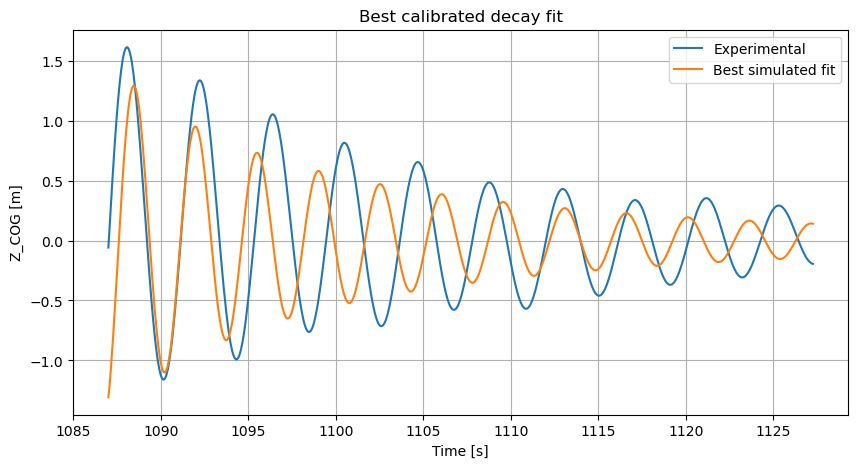

In [24]:
best_result = evaluate_case(
    c_lin=df_random.loc[0, "linear_damping"],
    c_quad=df_random.loc[0, "quadratic_damping"]
)

plt.figure(figsize=(10, 5))
plt.plot(t_exp, z_exp, label="Experimental")
plt.plot(t_exp, best_result["z_sim_fit"], label="Best simulated fit")

plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
plt.title("Best calibrated decay fit")
plt.grid(True)
plt.legend()
plt.show()